<a href="https://colab.research.google.com/github/SergioPAb/analysis-everpeak/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
from matplotlib.colors import LinearSegmentedColormap

# Configuración para visualización
sns.set_style("whitegrid")
sns.set_palette("Set2")

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# Mostrar primeras filas
print("\nPrimeras 5 filas del dataset:")
print(df.head())


Primeras 5 filas del dataset:
  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   e

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
-

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  miembro_premium      abandono  \
count               15000.000000  15000.000000     15000.000000  15000.000000   
mean                   20.149301      3.603693         0.139267      0.150733   
std                    10.880724      0.685300         0.346236      0.357801   
min                     0.000000      1.000000       

✍️ **Comentario:**

Diagnóstico inicial de variables numéricas

edad — Rango entre 18 y 75 años, con media de 38.3 años. Distribución normal típica para una base de clientes. Se corrigió el tipo de dato a int64.

nivel_ingreso — Rango entre 8,000 y 74,790, con media de 30,019 y mediana de 30,023 (media y mediana muy cercanas, distribución simétrica). No requiere transformación.

visitas_mes — Rango entre 1 y 25 visitas, con media de 10 y mediana de 10. Distribución simétrica. No requiere transformación.

compras_mes — Rango entre 0 y 8 compras, con media de 1.2 y mediana de 1. El 25% de los clientes tiene 0 compras (cuartil 1 = 0), lo que indica que hay clientes que visitan pero no compran. Distribución sesgada a la derecha. Requiere atención para análisis de correlación.

gasto_publicidad_dirigida — Rango entre 0 y 75.51, con media de 20.15 y mediana de 19.73. Distribución relativamente simétrica. No requiere transformación.

satisfaccion — Rango entre 1 y 5, con media de 3.6 y mediana de 3.6. Distribución normal, sin valores extremos. Podría convertirse a int64 por ser escala discreta, pero como tiene decimales (ej. 3.9, 2.3), se mantiene como float64.

ingreso_anual — Variable foco del análisis. Rango entre 0 y 244.69, con media de 36.59 y mediana de 30.71. El 25% de los clientes genera 0 ingresos (cuartil 1 = 0), lo que indica una distribución muy sesgada a la derecha. Requiere atención especial para el análisis de correlación, ya que la presencia de muchos ceros puede afectar las correlaciones. Se podría considerar análisis por segmentos.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("Valores únicos en miembro_premium:")
print(df['miembro_premium'].unique())

print("\nValores únicos en abandono:")
print(df['abandono'].unique())


Valores únicos en miembro_premium:
[0 1]

Valores únicos en abandono:
[0 1]



✍️ **Comentario**:

Diagnóstico inicial de variables binarias


miembro_premium — Variable binaria con valores 0 y 1. El 13.9% de los clientes son premium (media = 0.139), lo que indica una baja penetración de membresía premium. No requiere transformación adicional. Está correctamente codificada para análisis de correlación punto-biserial.

abandono — Variable binaria con valores 0 y 1. El 15.1% de los clientes han abandonado la plataforma (media = 0.151). No requiere transformación adicional. Está correctamente codificada para análisis de correlación punto-biserial.

Ambas columnas tienen únicamente dos valores posibles, por lo que no se requieren acciones de limpieza ni transformación adicional.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['tipo_dispositivo', 'region']

for col in columnas_categoricas:
    print(f"Número de valores únicos en {col}: {df[col].nunique()}")
    print(f"Valores únicos: {df[col].unique()}")
    print("-" * 30)

Número de valores únicos en tipo_dispositivo: 3
Valores únicos: ['móvil' 'tablet' 'escritorio']
------------------------------
Número de valores únicos en region: 4
Valores únicos: ['norte' 'sur' 'este' 'oeste']
------------------------------


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in columnas_categoricas:
    print(f"Distribución de {col}:")
    print(df[col].value_counts())
    print(f"\nPorcentajes:")
    print(df[col].value_counts(normalize=True) * 100)
    print("=" * 40)

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Porcentajes:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64
Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Porcentajes:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

tipo_dispositivo — Variable categórica con 3 valores únicos: 'móvil', 'escritorio' y 'tablet'. La categoría mayoritaria es 'móvil' con un 65.5%, seguida de 'escritorio' con 24.8% y 'tablet' con 9.7%. Esto es esperado para una plataforma de e-commerce. No requiere transformación adicional para el análisis de V de Cramér.

region — Variable categórica con 4 valores únicos: 'norte', 'sur', 'este' y 'oeste'. La distribución es relativamente equilibrada: 'norte' con 29.3%, 'oeste' con 25.4%, 'sur' con 24.8% y 'este' con 20.5%. No requiere transformación adicional para el análisis de V de Cramér.

Ambas variables están correctamente definidas como tipo object y no requieren codificación adicional para el análisis de correlación con V de Cramér.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

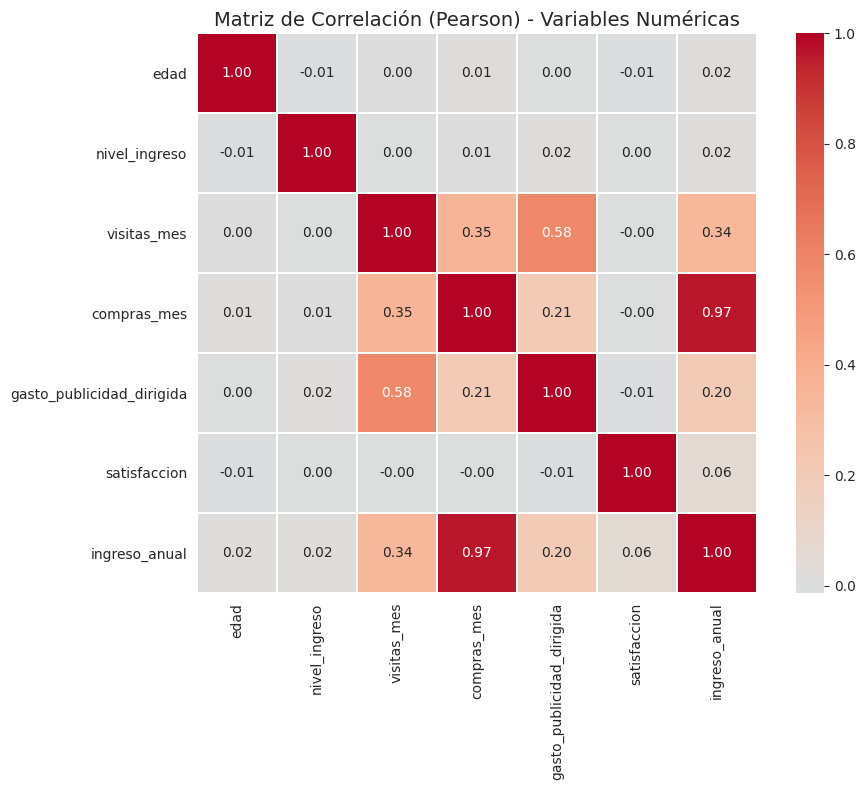

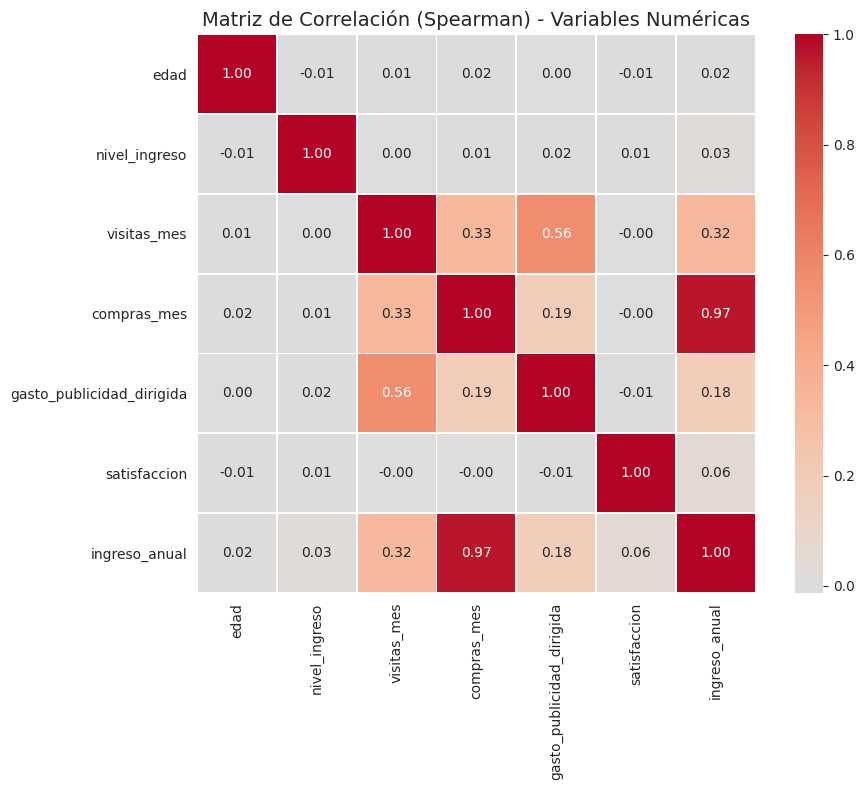

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
columnas_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
                      'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Pearson
corr_pearson = df[columnas_numericas].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación (Pearson) - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Spearman
corr_spearman = df[columnas_numericas].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlación (Spearman) - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()


✍️ **Comentario**:

Observaciones generales (Heatmap)  
- Se observa que la mayoría de las correlaciones entre variables numéricas son débiles o cercanas a cero, con valores entre -0.01 y 0.58. Las variables visitas_mes y gasto_publicidad_dirigida muestran una correlación moderada (0.58 en Pearson, 0.56 en Spearman), lo que sugiere que los clientes que más visitan la plataforma también reciben más gasto en publicidad dirigida. El resto de las variables presentan relaciones muy débiles, lo que indica que pocas variables individuales tienen una asociación lineal fuerte con el ingreso anual.

Observaciones respecto a `ingreso_anual`  
- La correlación con compras_mes es extremadamente alta (0.97), lo cual es esperable y no aporta valor analítico, ya que el ingreso anual es directamente proporcional al número de compras realizadas. Por esta razón, esta relación será excluida del análisis para enfocarnos en variables que ofrezcan información más relevante sobre el comportamiento del cliente.

Las correlaciones más interesantes para el análisis son: visitas_mes (0.34), gasto_publicidad_dirigida (0.20), satisfaccion (0.06), nivel_ingreso (0.02) y edad (0.02). Aunque son débiles, visitas_mes y gasto_publicidad_dirigida muestran cierta asociación con el ingreso, lo que sugiere que aumentar las visitas y una inversión publicitaria más dirigida podrían tener un impacto positivo, aunque limitado, en los ingresos generados por cliente.


### Scatterplot general

**No se incluirá un scatterplot general.**

Dado que la mayoría de las correlaciones entre variables son débiles (menores a 0.4 en valor absoluto), un scatterplot general con todas las variables numéricas generaría una matriz de gráficos de dispersión con poco valor informativo. La única relación fuerte (compras_mes vs ingreso_anual) es una relación obvia que no aporta valor analítico y será excluida del análisis. Un pairplot general sobrecargaría la visualización sin aportar insights relevantes. En su lugar, se generarán scatterplots enfocados únicamente en los pares de variables con relaciones moderadas que ofrecen información valiosa para el negocio.

**Pares a visualizar:**

- visitas_mes vs ingreso_anual

- gasto_publicidad_dirigida vs ingreso_anual

- visitas_mes vs gasto_publicidad_dirigida

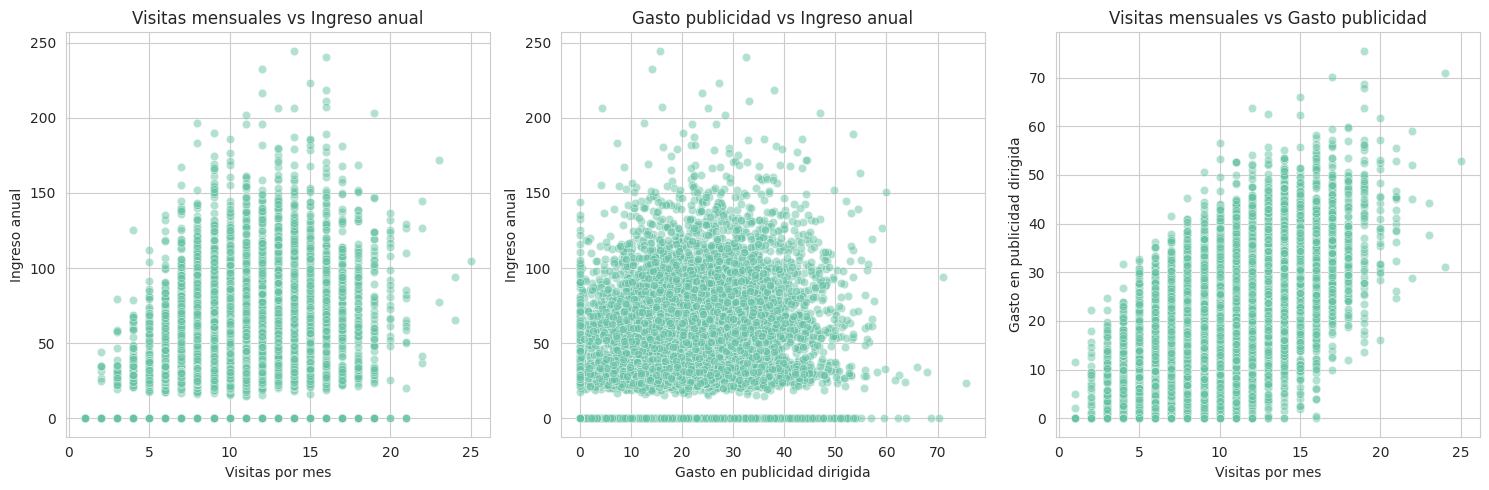

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatterplot 1: visitas_mes vs ingreso_anual
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', alpha=0.5, ax=axes[0])
axes[0].set_title('Visitas mensuales vs Ingreso anual')
axes[0].set_xlabel('Visitas por mes')
axes[0].set_ylabel('Ingreso anual')

# Scatterplot 2: gasto_publicidad_dirigida vs ingreso_anual
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', alpha=0.5, ax=axes[1])
axes[1].set_title('Gasto publicidad vs Ingreso anual')
axes[1].set_xlabel('Gasto en publicidad dirigida')
axes[1].set_ylabel('Ingreso anual')

# Scatterplot 3: visitas_mes vs gasto_publicidad_dirigida
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida', alpha=0.5, ax=axes[2])
axes[2].set_title('Visitas mensuales vs Gasto publicidad')
axes[2].set_xlabel('Visitas por mes')
axes[2].set_ylabel('Gasto en publicidad dirigida')

plt.tight_layout()
plt.show()

✍️ **Comentario**:

Scatterplot para pares clave

Observaciones iniciales (Scatterplot)

**visitas_mes vs ingreso_anual**

Dirección: Positiva (ligera tendencia ascendente)

Dispersión: Alta (los puntos están ampliamente distribuidos alrededor de la línea de tendencia)

Outliers: Se observan algunos puntos con ingresos muy altos (por encima de 150) combinados con visitas moderadas (10-15 visitas), lo que sugiere que el ingreso no está determinado únicamente por el número de visitas

Colinealidad: No se observa una relación lineal clara; la alta dispersión indica que otras variables no incluidas en este gráfico influyen en el ingreso anual

**gasto_publicidad_dirigida vs ingreso_anual**

Dirección: Positiva (tendencia ascendente leve)

Dispersión: Alta (los puntos se distribuyen ampliamente a lo largo del eje vertical para cada nivel de gasto)

Outliers: Se observan múltiples puntos con ingresos cercanos a 0 o muy bajos a pesar de tener gastos publicitarios entre 10-40, lo que sugiere que la publicidad dirigida no siempre se traduce en ingresos

Colinealidad: No se observa una relación clara; el gasto en publicidad no parece ser un predictor fuerte del ingreso anual

**visitas_mes vs gasto_publicidad_dirigida

Dirección: Positiva (tendencia ascendente más clara que en los casos anteriores)

Dispersión: Media (los puntos muestran una concentración más definida alrededor de la línea de tendencia)

Outliers: Se observan algunos puntos con altas visitas (20-25) y gastos publicitarios bajos (0-10), lo que podría indicar clientes que visitan orgánicamente sin publicidad dirigida

Colinealidad: La relación más clara entre las tres, consistente con la correlación moderada (0.58) observada en el heatmap; sugiere que existe una asociación consistente entre visitas y gasto publicitario

Resumen general: Los scatterplots confirman la debilidad de las relaciones con ingreso_anual, mostrando alta dispersión en ambos casos, y validan la relación moderada entre visitas_mes y gasto_publicidad_dirigida. La presencia de outliers en todas las variables sugiere que existen segmentos de clientes con comportamientos atípicos que podrían analizarse por separado.

## Sección 4 - Coeficientes de correlación y evidencia numérica

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes (Pearson)
variables_relevantes = ['visitas_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
corr_pearson = df[variables_relevantes].corr(method='pearson')
print("Correlación Pearson:")
print(corr_pearson)

Correlación Pearson:
                           visitas_mes  gasto_publicidad_dirigida  \
visitas_mes                   1.000000                   0.578947   
gasto_publicidad_dirigida     0.578947                   1.000000   
ingreso_anual                 0.337147                   0.197483   

                           ingreso_anual  
visitas_mes                     0.337147  
gasto_publicidad_dirigida       0.197483  
ingreso_anual                   1.000000  


In [ ]:
# Calcular correlación entre variables relevantes (Spearman)
corr_spearman = df[variables_relevantes].corr(method='spearman')
print("Correlación Spearman:")
print(corr_spearman)

Correlación Spearman:
                           visitas_mes  gasto_publicidad_dirigida  \
visitas_mes                   1.000000                   0.559267   
gasto_publicidad_dirigida     0.559267                   1.000000   
ingreso_anual                 0.320954                   0.184999   

                           ingreso_anual  
visitas_mes                     0.320954  
gasto_publicidad_dirigida       0.184999  
ingreso_anual                   1.000000  


**✍️ Comentario:
Observaciones de correlación**

**visitas_mes vs gasto_publicidad_dirigida**

Correlación: 0.58 (Pearson) / 0.56 (Spearman)

Dirección: Positiva

Magnitud: Moderada

Posible colinealidad: Esta es la relación más fuerte entre las variables analizadas. Indica que los clientes que más visitan la plataforma tienden a recibir más gasto en publicidad dirigida. La consistencia entre Pearson y Spearman sugiere que la relación es relativamente lineal y no está distorsionada por outliers.

**visitas_mes vs ingreso_anual**

Correlación: 0.34 (Pearson) / 0.32 (Spearman)

Dirección: Positiva

Magnitud: Débil a moderada

Posible colinealidad: Existe una relación positiva, pero la alta dispersión observada en el scatterplot indica que el ingreso anual no está fuertemente determinado por el número de visitas. La similitud entre Pearson y Spearman sugiere que no hay outliers extremos distorsionando la relación.

**gasto_publicidad_dirigida vs ingreso_anual**

Correlación: 0.20 (Pearson) / 0.18 (Spearman)

Dirección: Positiva

Magnitud: Débil

Posible colinealidad: La correlación es baja, lo que indica que el gasto en publicidad dirigida no tiene una fuerte asociación con el ingreso generado. La ligera diferencia entre Pearson y Spearman sugiere que podría haber algún outlier, aunque no es significativo. Esta relación débil sugiere que la inversión publicitaria no está siendo efectiva para generar ingresos adicionales.

**Resumen:** Las correlaciones confirman que la relación más relevante es entre visitas_mes y gasto_publicidad_dirigida (moderada positiva). Las relaciones con ingreso_anual son débiles (0.34 y 0.20), lo que sugiere que otras variables no incluidas en este análisis podrían ser mejores predictores del ingreso anual.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes (Punto-biserial)
from scipy.stats import pointbiserialr

columnas_binarias = ['miembro_premium', 'abandono']
columnas_numericas = ['visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

for binaria in columnas_binarias:
    print(f"\n--- Correlación Punto-biserial con {binaria} ---")
    for numerica in columnas_numericas:
        coef, p_value = pointbiserialr(df[binaria], df[numerica])
        print(f"{numerica}: {coef:.4f} (p-value: {p_value:.4f})")



--- Correlación Punto-biserial con miembro_premium ---
visitas_mes: -0.0127 (p-value: 0.1211)
compras_mes: 0.0034 (p-value: 0.6744)
gasto_publicidad_dirigida: 0.0027 (p-value: 0.7390)
satisfaccion: 0.0257 (p-value: 0.0016)
ingreso_anual: 0.0931 (p-value: 0.0000)

--- Correlación Punto-biserial con abandono ---
visitas_mes: -0.0089 (p-value: 0.2734)
compras_mes: 0.0083 (p-value: 0.3099)
gasto_publicidad_dirigida: -0.0046 (p-value: 0.5744)
satisfaccion: -0.0238 (p-value: 0.0035)
ingreso_anual: -0.0028 (p-value: 0.7295)


**✍️ Comentario: Observaciones Punto-biserial**

**miembro_premium vs variables numéricas**

Dirección: Mayormente positiva (excepto visitas_mes que es ligeramente negativa)

Magnitud: Baja en todos los casos (valores entre -0.01 y 0.09)

Las correlaciones más altas son con ingreso_anual (0.09), seguido de satisfaccion (0.03) y compras_mes (0.003). Esto sugiere que los miembros premium generan ligeramente más ingresos y tienen una satisfacción ligeramente mayor, aunque la relación es muy débil.

**abandono vs variables numéricas**

Dirección: Mayormente negativa (excepto compras_mes que es ligeramente positiva)

Magnitud: Muy baja (valores entre -0.02 y 0.01)

Las correlaciones son prácticamente nulas en todos los casos, con valores cercanos a cero. La relación más notable es con satisfaccion (-0.02), lo que indica que los clientes que abandonan tienden a tener una satisfacción ligeramente menor, aunque la magnitud es extremadamente baja.

**Resumen:** Ambas variables binarias (miembro_premium y abandono) presentan correlaciones muy débiles con las variables numéricas analizadas. Ninguna de las relaciones muestra una magnitud que sugiera una asociación relevante, lo que indica que estas variables binarias no son buenos predictores del comportamiento de uso o ingreso por sí solas. La relación más alta es entre miembro_premium e ingreso_anual (0.09), pero sigue siendo baja.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramers_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
variables_categoricas = ['tipo_dispositivo', 'region']

print("V de Cramér entre variables categóricas:")
for i in range(len(variables_categoricas)):
    for j in range(i+1, len(variables_categoricas)):
        col1 = variables_categoricas[i]
        col2 = variables_categoricas[j]
        v = cramers_v(df, col1, col2)
        print(f"{col1} vs {col2}: {v:.4f}")


V de Cramér entre variables categóricas:
tipo_dispositivo vs region: 0.0124


**✍️ Comentario: Observaciones V de Cramér**

**tipo_dispositivo vs region**

Valor V de Cramér: 0.0124

Magnitud: Muy baja (cercana a cero)

Interpretación: No existe una asociación relevante entre el tipo de dispositivo utilizado por el cliente y su región geográfica. El valor cercano a cero indica que la distribución de dispositivos es prácticamente independiente de la región, lo que sugiere que no hay patrones regionales significativos en la elección de dispositivo, y por lo tanto, no es necesario considerar esta relación en estrategias segmentadas por región.

**✍️ Hallazgos**

Hallazgo 1 — Relación entre visitas mensuales y gasto publicitario dirigido

Evidencia visual: ![image.png](attachment:beef886a-8f8c-491a-afde-ce59619dd938.png)

Evidencia numérica: Correlación de 0.58 (Pearson) y 0.56 (Spearman).

Interpretación: Los clientes que realizan más visitas mensuales tienden a recibir un mayor gasto en publicidad dirigida, lo que podría deberse a estrategias de remarketing que asignan más presupuesto a usuarios más activos o a que clientes con mayor engagement generan más datos que permiten una segmentación publicitaria más efectiva. No podemos afirmar que el gasto en publicidad dirigida sea la causa del aumento en las visitas, ni que las visitas sean la causa del mayor gasto publicitario, ya que la relación es correlacional y podría estar influenciada por otras variables no consideradas.

- Para el negocio, esta relación moderada sugiere que la inversión en publicidad dirigida está llegando a los usuarios más activos, pero se recomienda analizar la efectividad de la publicidad en términos de conversión a compras, no solo en términos de visitas.

Hallazgo 2 — Relación entre membresía premium e ingreso anual

Evidencia numérica: Correlación punto-biserial de 0.09 entre miembro_premium e ingreso_anual.

Interpretación: Los miembros premium generan ligeramente más ingresos que los no premium, pero la diferencia es muy pequeña (correlación de 0.09), lo que sugiere que la membresía premium no está generando un impacto significativo en el ingreso anual. No podemos afirmar que ser miembro premium cause un mayor ingreso anual, ya que la correlación es tan baja que cualquier relación observada podría deberse al azar o a factores no medidos en este análisis.

- Para el negocio, esto indica que el valor percibido del plan premium podría no estar alineado con los beneficios que ofrece, por lo que se recomienda revisar los beneficios del programa premium y evaluar si es necesario rediseñarlo para hacerlo más atractivo.

Hallazgo 3 — Relación entre visitas mensuales e ingreso anual

Evidencia visual: ![image.png](attachment:07140061-d4b7-45b2-8afa-1b42a1e4bf76.png)

Evidencia numérica: Correlación de 0.34 (Pearson) y 0.32 (Spearman).

Interpretación: Los clientes que realizan más visitas mensuales tienden a generar un ingreso anual ligeramente mayor, pero la alta dispersión indica que el ingreso no está determinado por el número de visitas, ya que muchos clientes visitan frecuentemente pero generan poco ingreso, mientras que otros con pocas visitas pueden generar ingresos altos. No podemos afirmar que aumentar las visitas mensuales cause un incremento en el ingreso anual, ya que la relación es débil y podría estar influenciada por otros factores como el ticket promedio de compra o la tasa de conversión.

- Para el negocio, esto sugiere que la estrategia no debe enfocarse únicamente en incrementar las visitas, sino en convertir esas visitas en compras efectivas, por lo que se recomienda analizar el funnel de conversión para identificar puntos de fricción y evaluar si el ticket promedio puede incrementarse mediante upselling o cross-selling.

Hallazgo 4 — Relación entre satisfacción y abandono

Evidencia numérica: Correlación punto-biserial de -0.02 entre satisfaccion y abandono.

Interpretación: Los clientes que abandonan la plataforma tienden a tener una satisfacción ligeramente menor, aunque la relación es prácticamente nula (correlación de -0.02), lo que indica que la satisfacción no es un factor determinante en la decisión de abandonar la plataforma. No podemos afirmar que la insatisfacción cause abandono, ya que la correlación es tan baja que cualquier relación observada podría deberse al azar o a factores no medidos en este análisis, como el precio o la competencia.

- Para el negocio, esto sugiere que el abandono no está fuertemente relacionado con la satisfacción, lo que indica que otros factores (como precio o competencia) podrían estar influyendo en la decisión de abandonar la plataforma, por lo que se recomienda investigar estas otras causas para implementar estrategias de retención más efectivas.

Hallazgo 5 — Relación entre variables categóricas

Evidencia numérica: V de Cramér de 0.0124 entre tipo_dispositivo y region.

Interpretación: No existe una asociación relevante entre el tipo de dispositivo utilizado por el cliente y su región geográfica, ya que el valor cercano a cero (0.0124) indica que la distribución de dispositivos es prácticamente independiente de la región, lo que sugiere que el acceso a diferentes dispositivos es homogéneo entre regiones. No podemos afirmar que exista una relación entre la ubicación geográfica del cliente y el dispositivo que utiliza, ya que la independencia observada sugiere que el acceso a diferentes dispositivos es homogéneo entre regiones.

- Para el negocio, esto implica que las estrategias de optimización de la plataforma no necesitan ser diferenciadas por región, lo que simplifica las decisiones de desarrollo y mantenimiento, permitiendo enfocar esfuerzos en mejorar la experiencia general de usuario sin necesidad de segmentar por región geográfica.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad: Este análisis identifica relaciones entre variables, pero no establece relaciones de causa y efecto. Por ejemplo, aunque existe una correlación moderada entre visitas mensuales y gasto publicitario dirigido, no podemos afirmar que una cause la otra. Para establecer causalidad se requerirían diseños experimentales como pruebas A/B o estudios longitudinales.

- Variables no incluidas: El análisis se limita a las variables disponibles en el dataset. Factores externos como la competencia, campañas de marketing fuera de la plataforma, eventos económicos o cambios en el comportamiento del consumidor no están capturados y podrían influir en los resultados observados.

- Sesgo de la muestra: Los datos corresponden a un solo año (2024) y podrían no ser representativos de otros períodos o de la totalidad de los clientes de NovaRetail+.

- Variables redundantes: La fuerte correlación entre compras_mes e ingreso_anual (0.97) fue excluida del análisis por ser obvia y no aportar valor analítico. Esto resalta la importancia de seleccionar variables que realmente aporten información relevante.

Distribución sesgada de variables: ingreso_anual presenta una distribución muy sesgada a la derecha (con el 25% de los clientes generando 0 ingresos), lo que puede afectar la interpretación de las correlaciones y la generalización de los resultados.
-

### **Próximos pasos**


**Probar segmentación adicional**

[Paso 1] Segmentar clientes por nivel de ingreso (nivel_ingreso) para analizar si la relación entre visitas e ingreso anual varía según el poder adquisitivo del cliente.

[Paso 2] Crear segmentos por edad (jóvenes, adultos, adultos mayores) para evaluar si el comportamiento de uso y el impacto de la publicidad dirigida difieren entre grupos etarios.

[Paso 3] Segmentar por tipo de dispositivo para analizar si los clientes que usan móvil tienen patrones de compra diferentes a los que usan escritorio o tablet.

**Incorporar variables externas**

[Paso 1] Incluir datos de estacionalidad para analizar si las visitas y compras varían según el mes del año (ej. temporada navideña, rebajas).

[Paso 2] Incorporar datos de competencia para evaluar si el abandono está relacionado con la oferta de otros competidores en la región.

**Profundizar en análisis predictivo**

[Paso 1] Construir modelos de regresión para identificar qué variables predicen mejor el ingreso_anual, controlando por el efecto de múltiples variables simultáneamente.

[Paso 2] Realizar análisis de cohortes para entender cómo evoluciona el comportamiento de los clientes a lo largo del tiempo después de su primer registro.

**Validación externa**

[Paso 1] Realizar pruebas A/B para validar si el incremento en gasto publicitario dirigido realmente aumenta las visitas y compras.

[Paso 2] Encuestar a clientes que abandonaron la plataforma para entender las causas reales de su decisión, complementando el análisis cuantitativo con información cualitativa.